Image Segmentation: Naive Bayes vs k-NN Comparison
Creating test image...
Visualizing training samples...


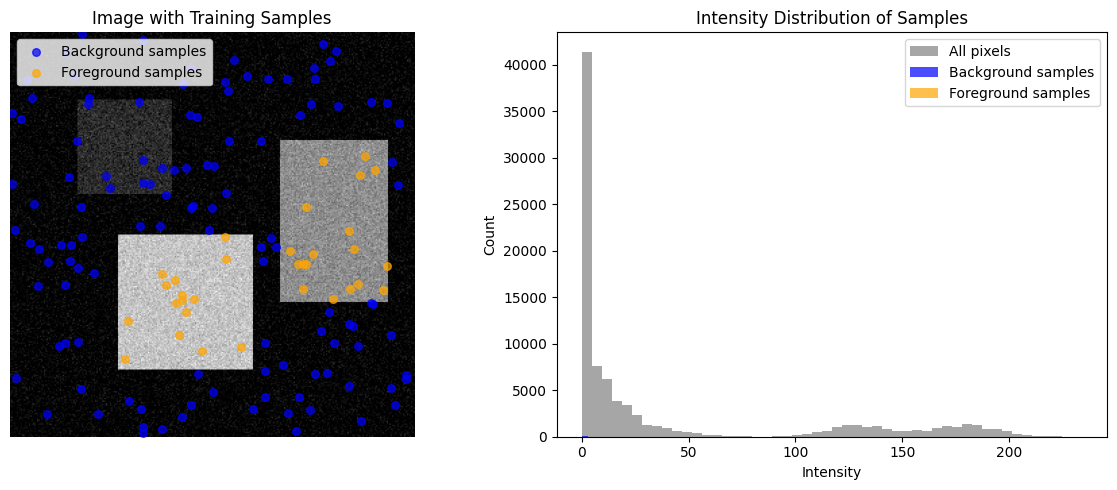

Background samples: 117
Foreground samples: 33
Background mean intensity: 7.79
Foreground mean intensity: 149.27
Applying segmentation methods...


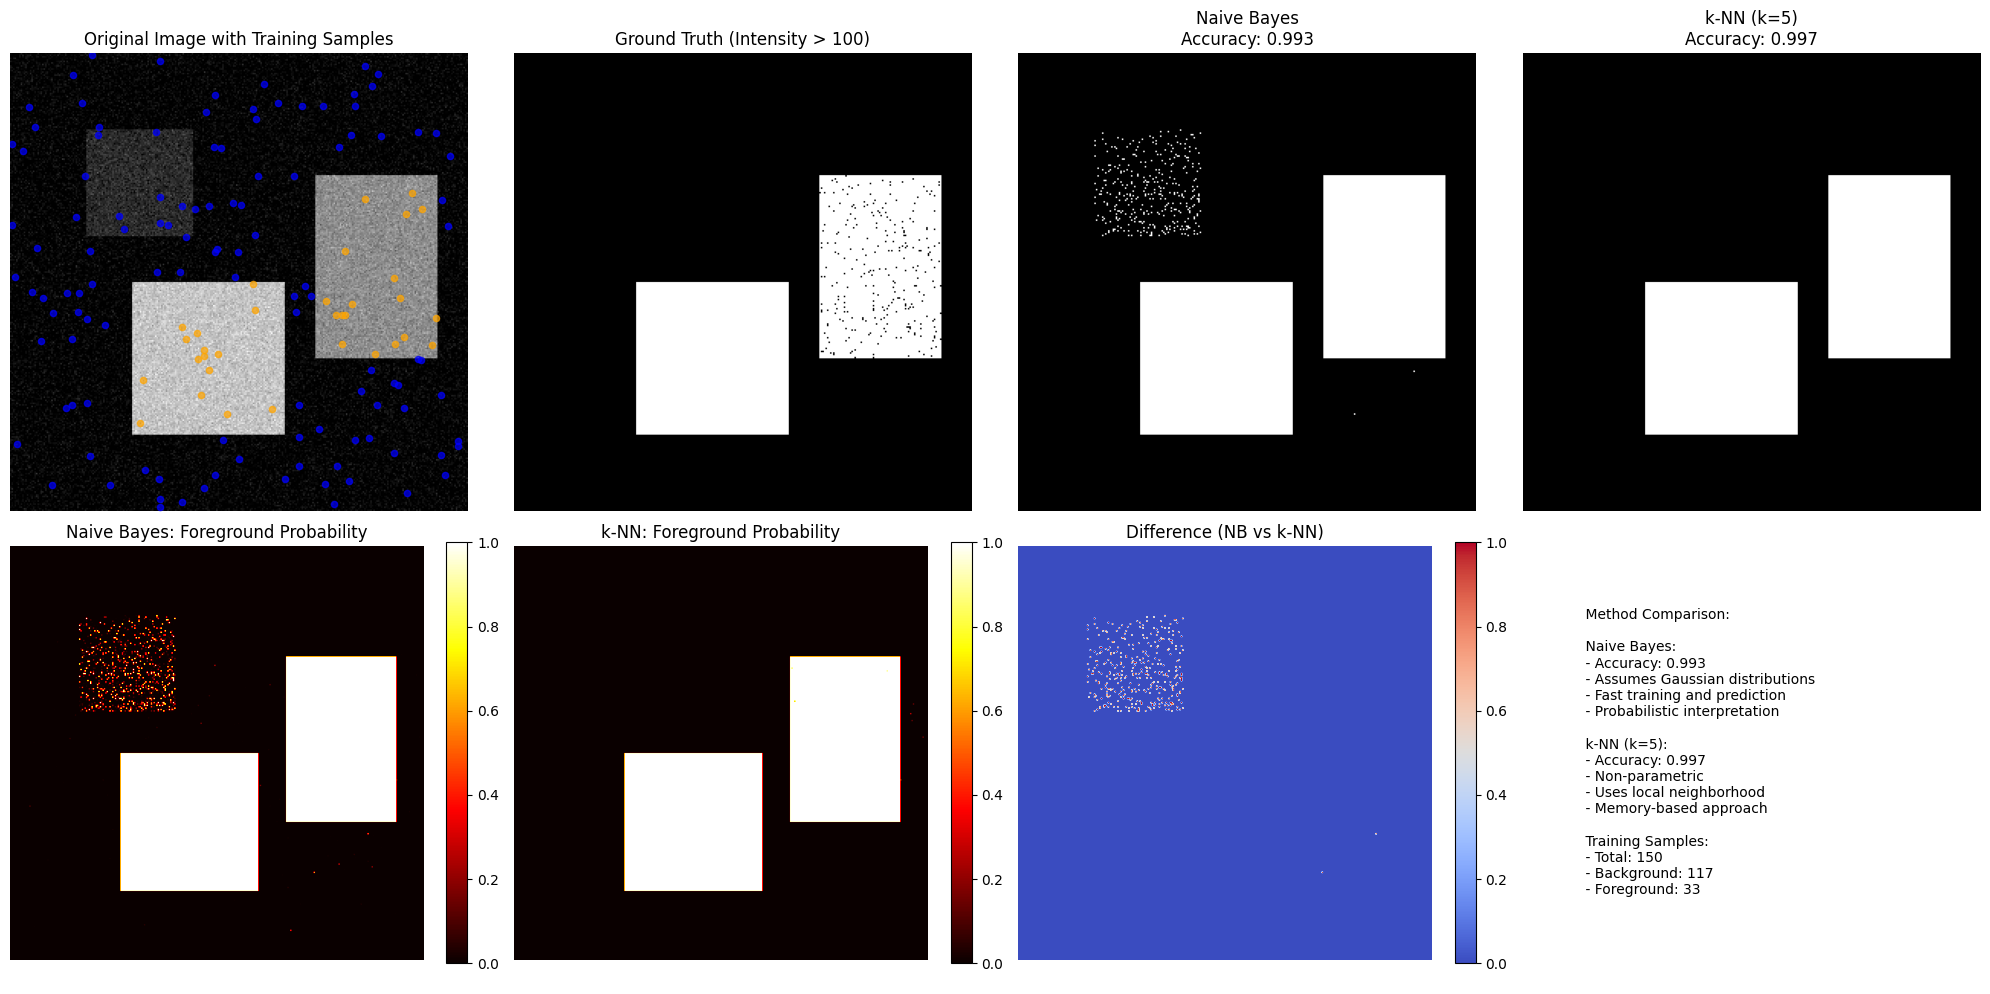


Trying with real image...


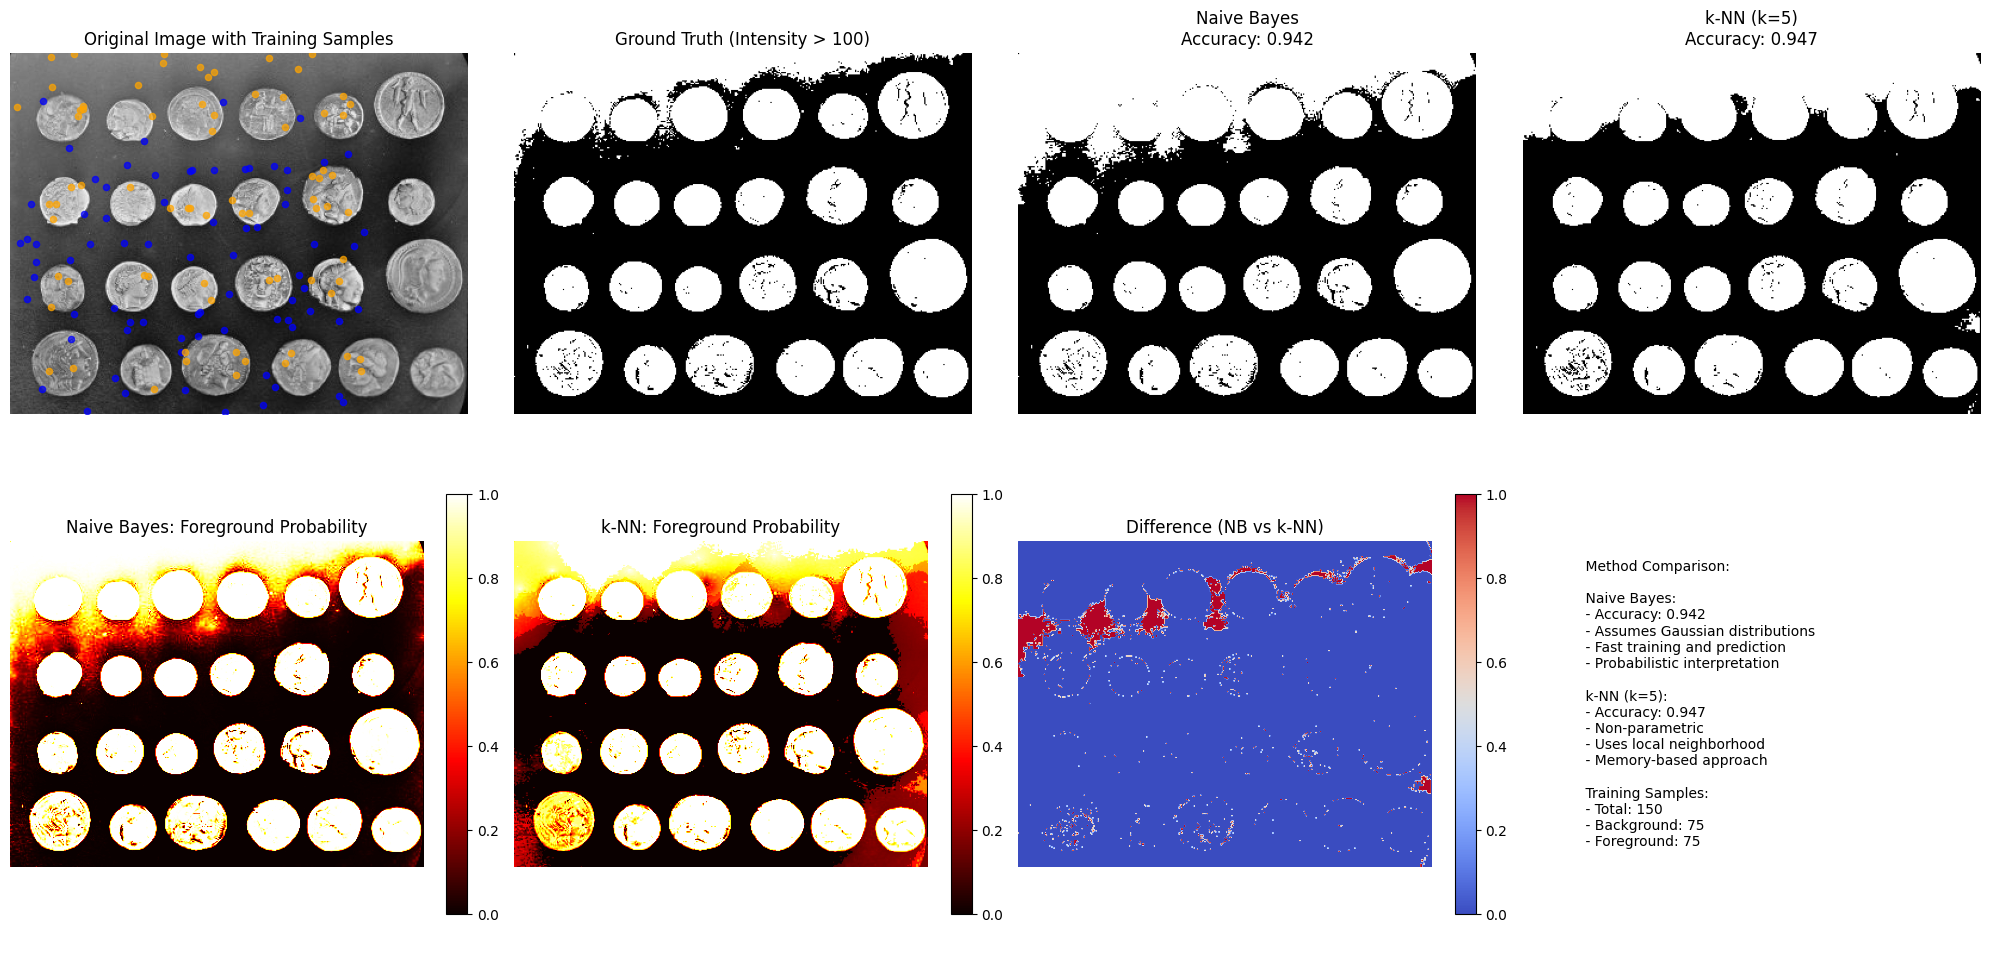

In [2]:
# --- Cell 1: Import Libraries ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from PIL import Image
import cv2
from skimage import data, segmentation
import requests
from io import BytesIO

# --- Cell 2: Create Test Image and Sample Training Pixels ---
def create_test_image_with_samples(size=(300, 300), n_samples=100):
    """
    Create a test image with randomly sampled training pixels
    """
    # Create a more complex test image
    image = np.zeros(size, dtype=np.uint8)
    
    # Create multiple regions with different intensities
    image[50:120, 50:120] = 40    # Dark rectangle
    image[150:250, 80:180] = 180  # Bright rectangle
    image[80:200, 200:280] = 130  # Medium rectangle
    
    # Add some Gaussian noise
    noise = np.random.normal(0, 15, size)
    image = np.clip(image.astype(np.float64) + noise, 0, 255).astype(np.uint8)
    
    # Randomly sample training pixels
    np.random.seed(42)  # For reproducibility
    train_coords = np.random.randint(0, min(size), size=(n_samples, 2))
    
    # Create training labels based on intensity thresholds
    train_labels = np.zeros(n_samples, dtype=int)
    for i, (y, x) in enumerate(train_coords):
        intensity = image[y, x]
        if intensity < 100:  # Background
            train_labels[i] = 0
        else:  # Foreground
            train_labels[i] = 1
    
    return image, train_coords, train_labels

def visualize_training_samples(image, train_coords, train_labels):
    """
    Visualize the image with training samples
    """
    plt.figure(figsize=(12, 5))
    
    # Original image with training samples
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    
    # Plot training samples
    bg_mask = train_labels == 0
    fg_mask = train_labels == 1
    
    plt.scatter(train_coords[bg_mask, 1], train_coords[bg_mask, 0], 
               c='blue', s=30, label='Background samples', alpha=0.7)
    plt.scatter(train_coords[fg_mask, 1], train_coords[fg_mask, 0], 
               c='orange', s=30, label='Foreground samples', alpha=0.7)
    plt.title('Image with Training Samples')
    plt.legend()
    plt.axis('off')
    
    # Histogram with sample distributions
    plt.subplot(1, 2, 2)
    plt.hist(image.flatten(), bins=50, alpha=0.7, color='gray', label='All pixels')
    
    # Plot sample intensities
    bg_intensities = [image[y, x] for (y, x), label in zip(train_coords, train_labels) if label == 0]
    fg_intensities = [image[y, x] for (y, x), label in zip(train_coords, train_labels) if label == 1]
    
    plt.hist(bg_intensities, bins=20, alpha=0.7, color='blue', label='Background samples')
    plt.hist(fg_intensities, bins=20, alpha=0.7, color='orange', label='Foreground samples')
    plt.xlabel('Intensity')
    plt.ylabel('Count')
    plt.title('Intensity Distribution of Samples')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"Background samples: {len(bg_intensities)}")
    print(f"Foreground samples: {len(fg_intensities)}")
    print(f"Background mean intensity: {np.mean(bg_intensities):.2f}")
    print(f"Foreground mean intensity: {np.mean(fg_intensities):.2f}")

# --- Cell 3: Naive Bayes Segmentation ---
def naive_bayes_segmentation(image, train_coords, train_labels):
    """
    Perform segmentation using Naive Bayes classifier
    """
    # Prepare training data
    X_train = []
    y_train = train_labels
    
    for (y, x), label in zip(train_coords, train_labels):
        # Use pixel intensity and spatial information
        intensity = image[y, x]
        # You can add more features here (e.g., local texture)
        X_train.append([intensity, x, y])  # Intensity + spatial coordinates
    
    X_train = np.array(X_train)
    
    # Train Naive Bayes classifier
    nb_classifier = GaussianNB()
    nb_classifier.fit(X_train, y_train)
    
    # Prepare test data (all pixels in the image)
    h, w = image.shape
    coordinates = np.array([[y, x] for y in range(h) for x in range(w)])
    intensities = image.flatten()
    
    X_test = np.column_stack([intensities, coordinates[:, 1], coordinates[:, 0]])
    
    # Predict all pixels
    nb_predictions = nb_classifier.predict(X_test)
    nb_segmentation = nb_predictions.reshape((h, w))
    
    # Get probability maps
    nb_probabilities = nb_classifier.predict_proba(X_test)
    nb_bg_prob = nb_probabilities[:, 0].reshape((h, w))
    nb_fg_prob = nb_probabilities[:, 1].reshape((h, w))
    
    return nb_segmentation, nb_bg_prob, nb_fg_prob, nb_classifier

# --- Cell 4: k-NN Segmentation ---
def knn_segmentation(image, train_coords, train_labels, k=5):
    """
    Perform segmentation using k-NN classifier
    """
    # Prepare training data
    X_train = []
    y_train = train_labels
    
    for (y, x), label in zip(train_coords, train_labels):
        intensity = image[y, x]
        X_train.append([intensity, x, y])  # Intensity + spatial coordinates
    
    X_train = np.array(X_train)
    
    # Train k-NN classifier
    knn_classifier = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn_classifier.fit(X_train, y_train)
    
    # Prepare test data
    h, w = image.shape
    coordinates = np.array([[y, x] for y in range(h) for x in range(w)])
    intensities = image.flatten()
    
    X_test = np.column_stack([intensities, coordinates[:, 1], coordinates[:, 0]])
    
    # Predict all pixels
    knn_predictions = knn_classifier.predict(X_test)
    knn_segmentation = knn_predictions.reshape((h, w))
    
    # Get probability maps
    knn_probabilities = knn_classifier.predict_proba(X_test)
    knn_bg_prob = knn_probabilities[:, 0].reshape((h, w))
    knn_fg_prob = knn_probabilities[:, 1].reshape((h, w))
    
    return knn_segmentation, knn_bg_prob, knn_fg_prob, knn_classifier

# --- Cell 5: Compare and Visualize Results ---
def compare_segmentation_methods(image, train_coords, train_labels):
    """
    Compare Naive Bayes and k-NN segmentation results
    """
    # Apply both methods
    nb_seg, nb_bg_prob, nb_fg_prob, nb_clf = naive_bayes_segmentation(
        image, train_coords, train_labels)
    
    knn_seg, knn_bg_prob, knn_fg_prob, knn_clf = knn_segmentation(
        image, train_coords, train_labels, k=5)
    
    # Create ground truth for evaluation (based on simple thresholding)
    ground_truth = (image > 100).astype(int)
    
    # Calculate accuracies
    nb_accuracy = accuracy_score(ground_truth.flatten(), nb_seg.flatten())
    knn_accuracy = accuracy_score(ground_truth.flatten(), knn_seg.flatten())
    
    # Visualize results
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    # Original image with samples
    axes[0, 0].imshow(image, cmap='gray')
    bg_mask = train_labels == 0
    fg_mask = train_labels == 1
    axes[0, 0].scatter(train_coords[bg_mask, 1], train_coords[bg_mask, 0], 
                      c='blue', s=20, alpha=0.7)
    axes[0, 0].scatter(train_coords[fg_mask, 1], train_coords[fg_mask, 0], 
                      c='orange', s=20, alpha=0.7)
    axes[0, 0].set_title('Original Image with Training Samples')
    axes[0, 0].axis('off')
    
    # Ground truth
    axes[0, 1].imshow(ground_truth, cmap='gray')
    axes[0, 1].set_title('Ground Truth (Intensity > 100)')
    axes[0, 1].axis('off')
    
    # Naive Bayes segmentation
    axes[0, 2].imshow(nb_seg, cmap='gray')
    axes[0, 2].set_title(f'Naive Bayes\nAccuracy: {nb_accuracy:.3f}')
    axes[0, 2].axis('off')
    
    # k-NN segmentation
    axes[0, 3].imshow(knn_seg, cmap='gray')
    axes[0, 3].set_title(f'k-NN (k=5)\nAccuracy: {knn_accuracy:.3f}')
    axes[0, 3].axis('off')
    
    # Naive Bayes probability map
    prob_map_nb = axes[1, 0].imshow(nb_fg_prob, cmap='hot', vmin=0, vmax=1)
    axes[1, 0].set_title('Naive Bayes: Foreground Probability')
    axes[1, 0].axis('off')
    plt.colorbar(prob_map_nb, ax=axes[1, 0], fraction=0.046)
    
    # k-NN probability map
    prob_map_knn = axes[1, 1].imshow(knn_fg_prob, cmap='hot', vmin=0, vmax=1)
    axes[1, 1].set_title('k-NN: Foreground Probability')
    axes[1, 1].axis('off')
    plt.colorbar(prob_map_knn, ax=axes[1, 1], fraction=0.046)
    
    # Difference map
    difference = np.abs(nb_seg - knn_seg)
    diff_map = axes[1, 2].imshow(difference, cmap='coolwarm', vmin=0, vmax=1)
    axes[1, 2].set_title('Difference (NB vs k-NN)')
    axes[1, 2].axis('off')
    plt.colorbar(diff_map, ax=axes[1, 2], fraction=0.046)
    
    # Method comparison info
    axes[1, 3].axis('off')
    comparison_text = f"""
    Method Comparison:
    
    Naive Bayes:
    - Accuracy: {nb_accuracy:.3f}
    - Assumes Gaussian distributions
    - Fast training and prediction
    - Probabilistic interpretation
    
    k-NN (k=5):
    - Accuracy: {knn_accuracy:.3f}
    - Non-parametric
    - Uses local neighborhood
    - Memory-based approach
    
    Training Samples:
    - Total: {len(train_labels)}
    - Background: {np.sum(train_labels == 0)}
    - Foreground: {np.sum(train_labels == 1)}
    """
    axes[1, 3].text(0.1, 0.5, comparison_text, transform=axes[1, 3].transAxes,
                   fontsize=10, verticalalignment='center')
    
    plt.tight_layout()
    plt.show()
    
    return nb_seg, knn_seg, nb_clf, knn_clf

# --- Cell 6: Test with Real Image (Optional) ---
def load_and_process_real_image():
    """
    Load a real image for segmentation
    """
    try:
        # Load a sample image from skimage
        image = data.coins()
        
        # Create synthetic training samples
        h, w = image.shape
        n_samples = 150
        
        np.random.seed(42)
        train_coords = np.random.randint(0, min(h, w), size=(n_samples, 2))
        train_labels = np.zeros(n_samples, dtype=int)
        
        # Label based on intensity (simple threshold)
        for i, (y, x) in enumerate(train_coords):
            if image[y, x] < 100:  # Dark regions as background
                train_labels[i] = 0
            else:  # Bright regions as foreground
                train_labels[i] = 1
                
        return image, train_coords, train_labels
        
    except Exception as e:
        print(f"Could not load real image: {e}")
        return None, None, None

# --- Cell 7: Main Execution ---
def main():
    """
    Main function to demonstrate both methods
    """
    print("Image Segmentation: Naive Bayes vs k-NN Comparison")
    print("=" * 50)
    
    # Create test image
    print("Creating test image...")
    image, train_coords, train_labels = create_test_image_with_samples(
        size=(300, 300), n_samples=150)
    
    # Visualize training samples
    print("Visualizing training samples...")
    visualize_training_samples(image, train_coords, train_labels)
    
    # Compare segmentation methods
    print("Applying segmentation methods...")
    nb_result, knn_result, nb_clf, knn_clf = compare_segmentation_methods(
        image, train_coords, train_labels)
    
    # Try with real image (optional)
    print("\nTrying with real image...")
    real_image, real_coords, real_labels = load_and_process_real_image()
    if real_image is not None:
        compare_segmentation_methods(real_image, real_coords, real_labels)

if __name__ == "__main__":
    main()